# DNH Total Monthly Water-Demand Analysis

This notebook presents an exploratory analysis of the validated monthly DNH_total dataset. It examines demand behaviour, weather seasonality, demographics, system state, driver relationships, and lead-lag signals.

The analysis is intended to support transparent, reproducible water-demand forecasting.

## 1. Analysis setup

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.features.phase4_data_loader import get_configured_dataset_paths, load_dnh_total_dataset

CONFIG_PATH = PROJECT_ROOT / 'configs' / 'synthetic_dnh_total_v2.json'
FIGURE_DIR = PROJECT_ROOT / 'outputs' / 'figures' / 'eda'
REPORT_DIR = PROJECT_ROOT / 'outputs' / 'reports'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', lambda value: f'{value:,.3f}')

## 2. Dataset overview

In [2]:
paths = get_configured_dataset_paths(CONFIG_PATH)
df = load_dnh_total_dataset(CONFIG_PATH)
df['month'] = df.index.month
df['year'] = df.index.year
df['quarter'] = df.index.quarter
overview = pd.Series({
    'dataset_path': str(paths['dataset_path']),
    'metadata_path': str(paths['metadata_path']),
    'area_id': ', '.join(df['area_id'].unique()),
    'rows': len(df),
    'columns': len(df.columns),
    'start_date': df.index.min().strftime('%Y-%m-%d'),
    'end_date': df.index.max().strftime('%Y-%m-%d'),
    'frequency': 'monthly start',
})
display(overview.to_frame('value'))
assert len(df) == 180
assert df.index.is_monotonic_increasing
assert df['area_id'].eq('DNH_total').all()

,value
dataset_path,data\synthetic\raw\synthetic_dnh_total_monthly...
metadata_path,data\synthetic\metadata\synthetic_dnh_total_mo...
area_id,DNH_total
rows,180
columns,20
start_date,2010-01-01
end_date,2024-12-01
frequency,monthly start


## 3. Demand behaviour and seasonality

,demand_m3
min,"1,930,072.000"
25%,"3,193,567.125"
50%,"3,652,210.900"
75%,"4,122,357.950"
max,"5,487,536.000"
mean,"3,660,509.559"
std,"697,758.949"


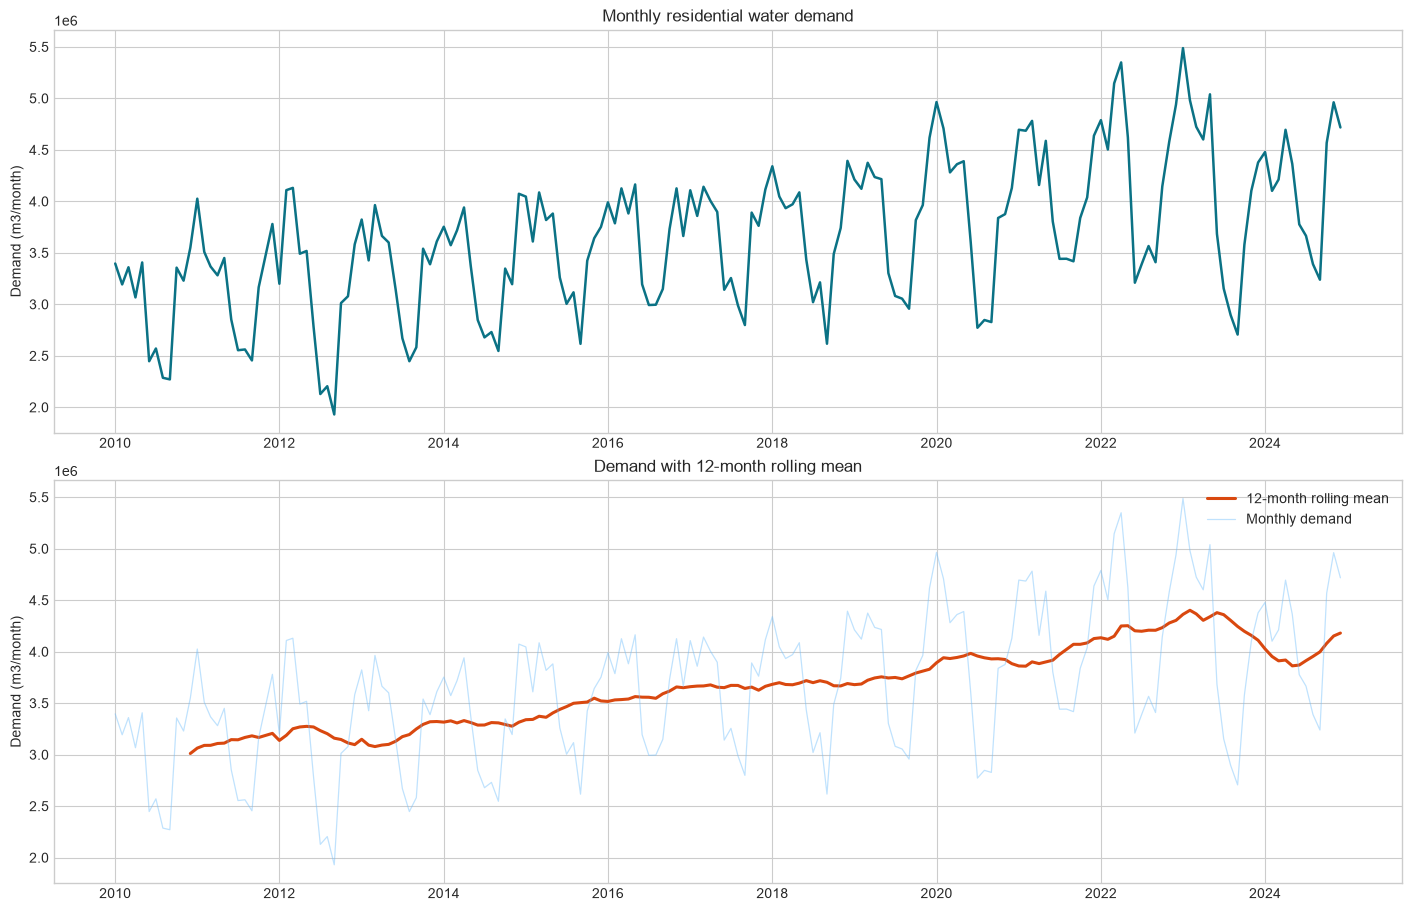

,mean,std,min,max
month,,,,
1,"4,220,230.080","598,834.165","3,199,403.800","5,487,536.000"
2,"4,013,947.553","523,998.911","3,192,704.700","4,980,403.500"
3,"4,155,965.913","485,544.903","3,359,635.500","5,145,259.200"
4,"4,034,346.607","577,251.467","3,066,705.600","5,348,631.400"
5,"4,039,042.520","508,310.432","3,371,594.900","5,038,929.300"
6,"3,232,099.613","391,166.616","2,447,053.500","3,803,582.000"
7,"2,958,084.133","402,147.573","2,128,206.200","3,664,888.000"
8,"2,915,826.560","411,558.950","2,204,283.500","3,565,726.200"
9,"2,767,883.047","415,724.118","1,930,072.000","3,417,316.900"


In [3]:
target = 'residential_water_demand_m3'
display(df[target].describe()[['min','25%','50%','75%','max','mean','std']].to_frame('demand_m3'))
fig, axes = plt.subplots(2, 1, figsize=(14, 9), constrained_layout=True)
axes[0].plot(df.index, df[target], color='#0b7285', linewidth=1.8)
axes[0].set(title='Monthly residential water demand', ylabel='Demand (m3/month)')
axes[1].plot(df.index, df[target].rolling(12).mean(), color='#d9480f', linewidth=2.2, label='12-month rolling mean')
axes[1].plot(df.index, df[target], color='#74c0fc', alpha=0.45, linewidth=0.9, label='Monthly demand')
axes[1].set(title='Demand with 12-month rolling mean', ylabel='Demand (m3/month)')
axes[1].legend()
fig.savefig(FIGURE_DIR / '01_target_demand_trend.png', dpi=160)
plt.show()
monthly_target = df.groupby('month')[target].agg(['mean','std','min','max'])
display(monthly_target)

## 4. Weather and climate patterns

Monthly profiles and monsoon versus dry-season comparisons identify the dominant seasonal signals.

,rainfall_mm,temp_max_c,temp_min_c,humidity_max_pct,humidity_min_pct,wind_speed_kmh,solar_radiation_mj_m2,sunshine_hours
month,,,,,,,,
1,90.926,35.651,24.422,80.367,55.513,6.564,410.583,208.233
2,88.088,35.538,23.217,79.700,55.627,5.763,403.933,206.387
3,77.351,34.577,21.993,80.653,54.300,5.519,417.721,209.807
4,84.120,32.519,19.680,79.567,56.293,5.555,412.929,209.287
5,97.728,30.337,16.578,79.733,53.173,6.064,406.297,207.600
6,347.063,28.684,16.521,94.620,64.893,6.928,299.005,138.300
7,300.323,27.928,16.502,95.107,64.700,6.800,307.453,134.553
8,297.025,28.961,15.415,94.113,65.513,6.850,268.155,134.853
9,347.019,29.479,18.104,95.240,64.313,6.655,299.993,132.713


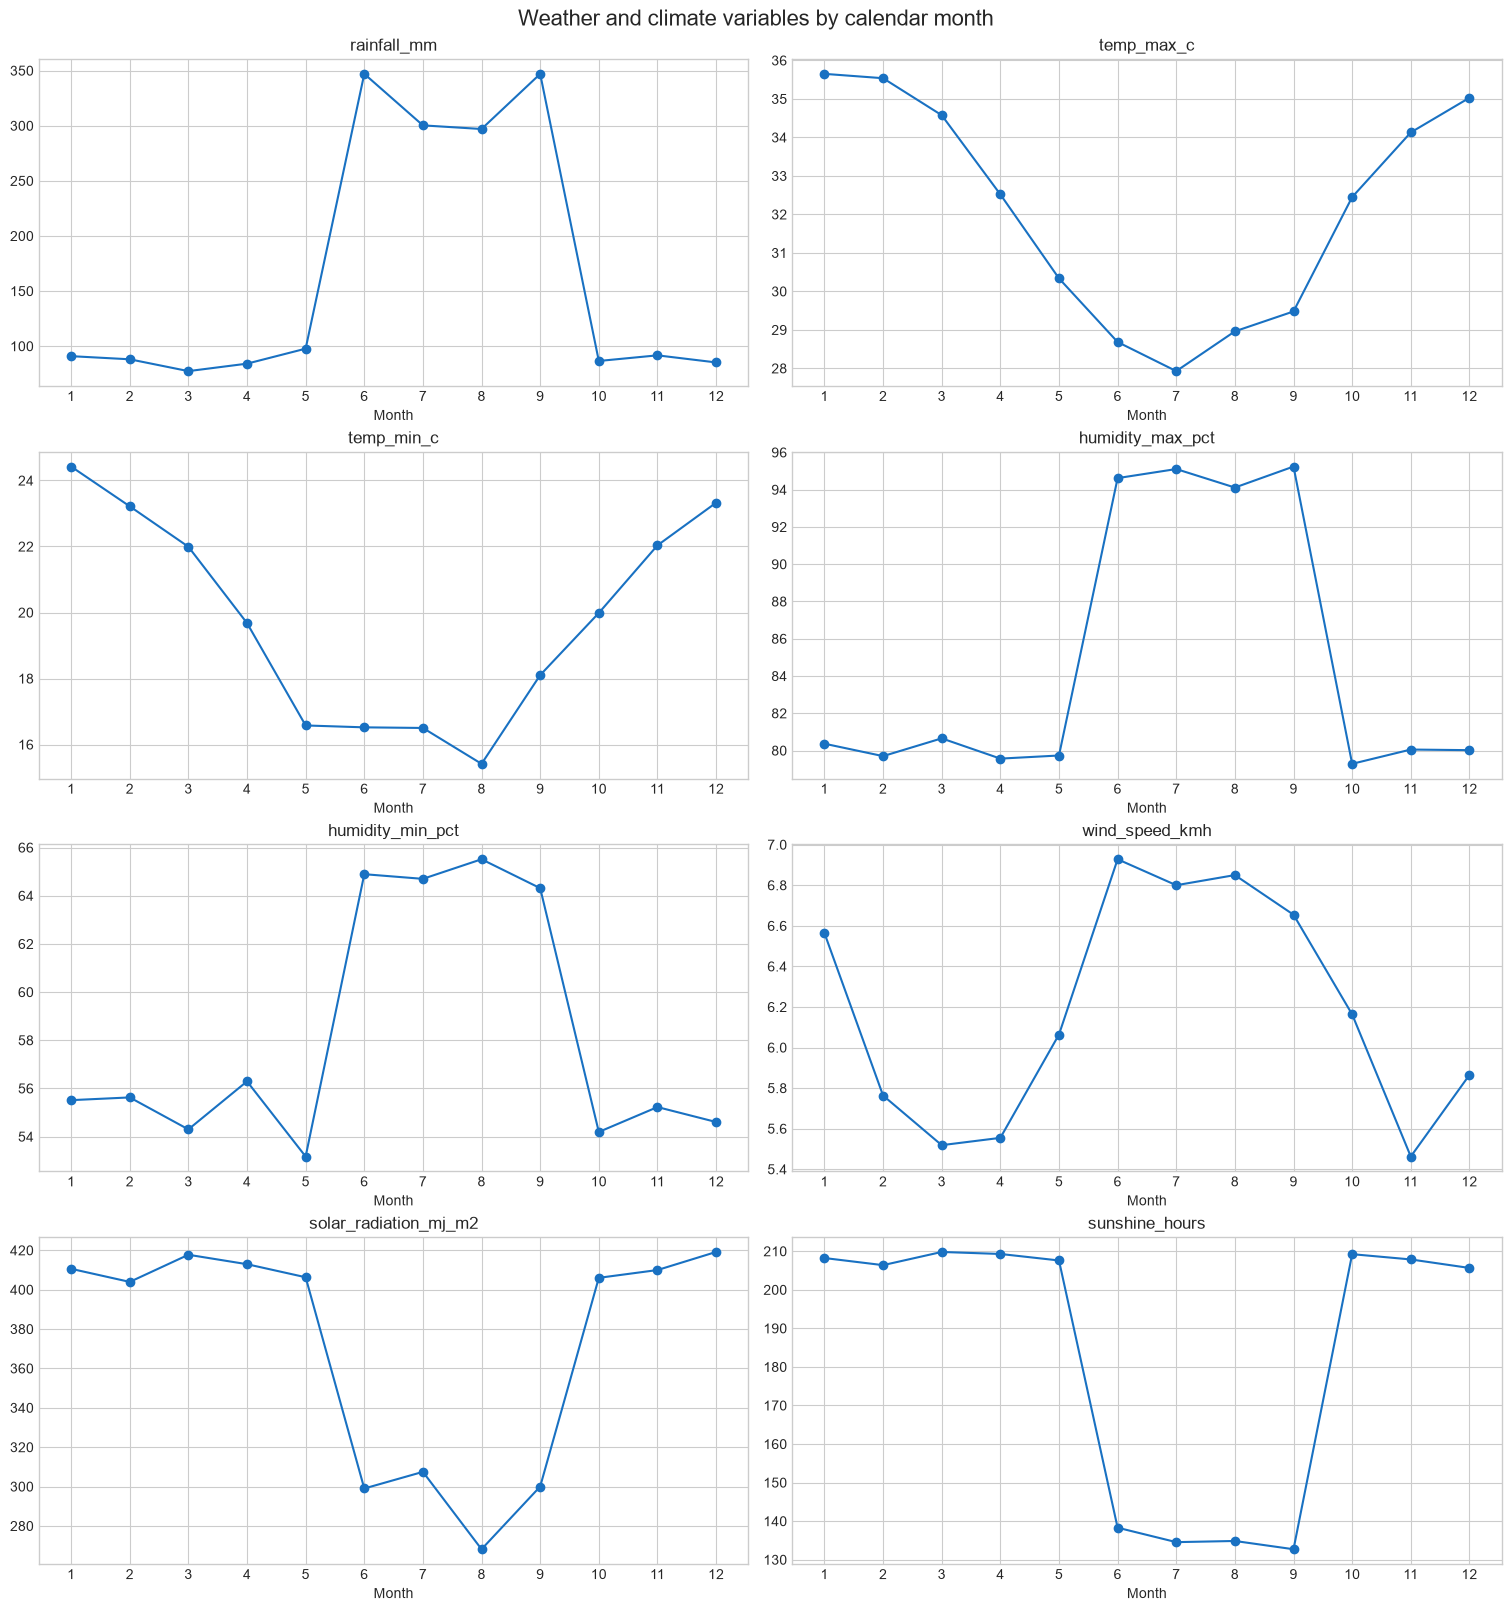

season,Monsoon,Dry season
rainfall_mm,322.858,87.711
temp_max_c,28.763,33.779
temp_min_c,16.636,21.404
humidity_max_pct,94.770,79.922
humidity_min_pct,64.855,54.867
wind_speed_kmh,6.808,5.869
solar_radiation_mj_m2,293.651,410.821
sunshine_hours,135.105,208.009


,mean,std,min,max
season,,,,
Monsoon,"2,968,473.338","429,552.422","1,930,072.000","3,803,582.000"
Dry season,"4,006,527.670","527,883.184","3,011,583.200","5,487,536.000"


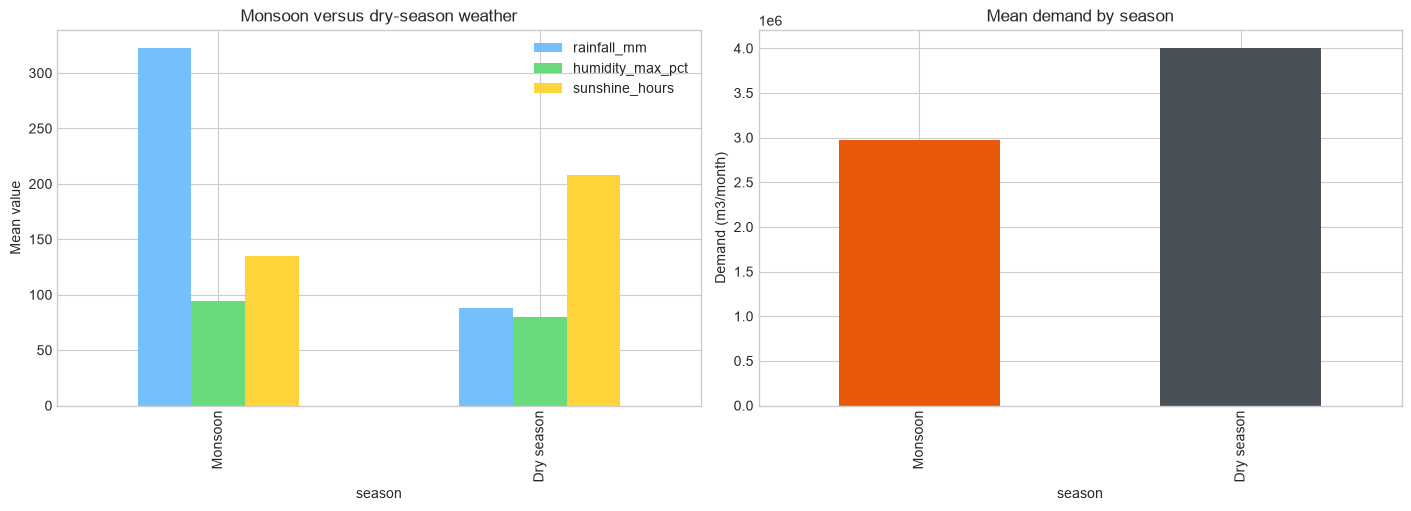

In [4]:
config = json.loads(CONFIG_PATH.read_text())
monsoon_months = config['weather']['monsoon_months']
weather_columns = ['rainfall_mm','temp_max_c','temp_min_c','humidity_max_pct','humidity_min_pct','wind_speed_kmh','solar_radiation_mj_m2','sunshine_hours']
weather_monthly = df.groupby('month')[weather_columns].mean()
display(weather_monthly)
fig, axes = plt.subplots(4, 2, figsize=(15, 16), constrained_layout=True)
for ax, column in zip(axes.flat, weather_columns):
    ax.plot(weather_monthly.index, weather_monthly[column], marker='o', color='#1971c2')
    ax.set(title=column, xlabel='Month')
    ax.set_xticks(range(1, 13))
fig.suptitle('Weather and climate variables by calendar month', fontsize=16)
fig.savefig(FIGURE_DIR / '02_weather_monthly_profiles.png', dpi=160)
plt.show()
df['season'] = np.where(df['month'].isin(monsoon_months), 'Monsoon', 'Dry season')
seasonal_weather = df.groupby('season')[weather_columns].mean().reindex(['Monsoon','Dry season'])
seasonal_target = df.groupby('season')[target].agg(['mean','std','min','max']).reindex(['Monsoon','Dry season'])
display(seasonal_weather.T)
display(seasonal_target)
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
seasonal_weather[['rainfall_mm','humidity_max_pct','sunshine_hours']].plot(kind='bar', ax=axes[0], color=['#74c0fc','#69db7c','#ffd43b'])
axes[0].set(title='Monsoon versus dry-season weather', ylabel='Mean value')
seasonal_target['mean'].plot(kind='bar', ax=axes[1], color=['#e8590c','#495057'])
axes[1].set(title='Mean demand by season', ylabel='Demand (m3/month)')
fig.savefig(FIGURE_DIR / '03_monsoon_dry_comparison.png', dpi=160, bbox_inches='tight')
plt.show()

## 5. Demographics and system-state behaviour

,first,last,min,max,growth_pct
total_population,865379,1254185,865220,1254185,44.929
urban_population,249915,548979,249915,548979,119.666
total_households,175594,243772,174868,244603,38.827


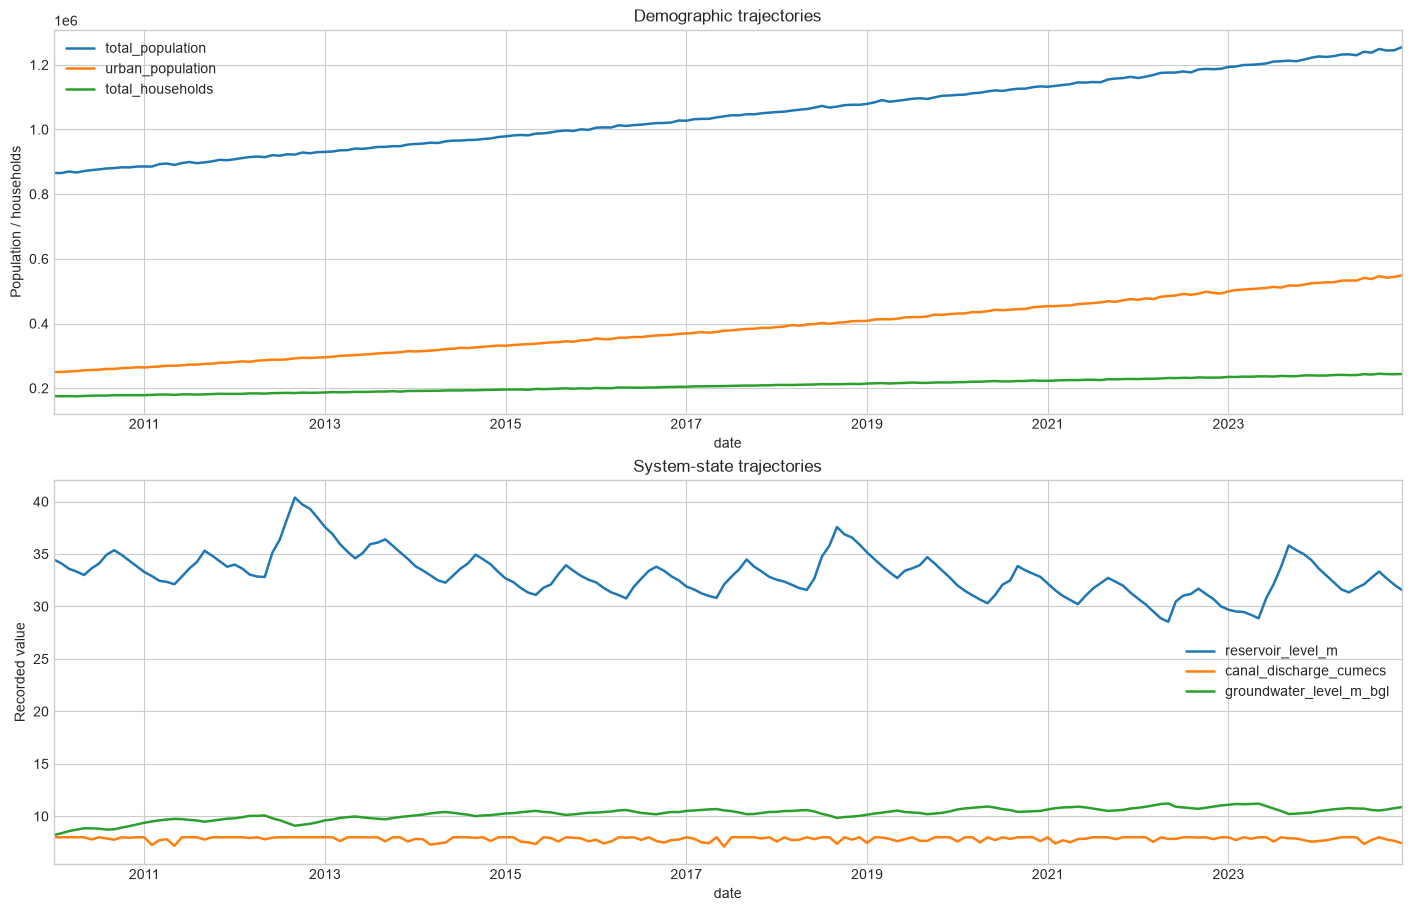

,reservoir_level_m,canal_discharge_cumecs,groundwater_level_m_bgl
month,,,
1,33.063,7.860,10.167
2,32.617,7.813,10.257
3,32.109,7.739,10.345
4,31.708,7.778,10.413
5,31.403,7.807,10.472
6,32.437,7.861,10.349
7,33.249,7.908,10.243
8,33.999,7.915,10.129
9,34.951,7.844,10.002


In [5]:
demographic_columns = ['total_population','urban_population','total_households']
state_columns = ['reservoir_level_m','canal_discharge_cumecs','groundwater_level_m_bgl']
demographic_summary = pd.DataFrame({
    'first': df[demographic_columns].iloc[0],
    'last': df[demographic_columns].iloc[-1],
    'min': df[demographic_columns].min(),
    'max': df[demographic_columns].max(),
})
demographic_summary['growth_pct'] = (demographic_summary['last'] / demographic_summary['first'] - 1) * 100
display(demographic_summary)
fig, axes = plt.subplots(2, 1, figsize=(14, 9), constrained_layout=True)
df[demographic_columns].plot(ax=axes[0], linewidth=1.8)
axes[0].set(title='Demographic trajectories', ylabel='Population / households')
df[state_columns].plot(ax=axes[1], linewidth=1.8)
axes[1].set(title='System-state trajectories', ylabel='Recorded value')
fig.savefig(FIGURE_DIR / '04_demographics_and_system_state.png', dpi=160)
plt.show()
display(df.groupby('month')[state_columns].mean())

## 6. Relationships between demand and major drivers

Correlation is descriptive only. The lead-lag analysis helps identify useful historical predictors, but it does not establish causality.

,correlation_with_demand
humidity_max_pct,-0.687
humidity_min_pct,-0.655
rainfall_mm,-0.637
reservoir_level_m,-0.612
wind_speed_kmh,-0.162
canal_discharge_cumecs,-0.141
temp_min_c,0.447
solar_radiation_mj_m2,0.489
urban_population,0.534
total_households,0.536


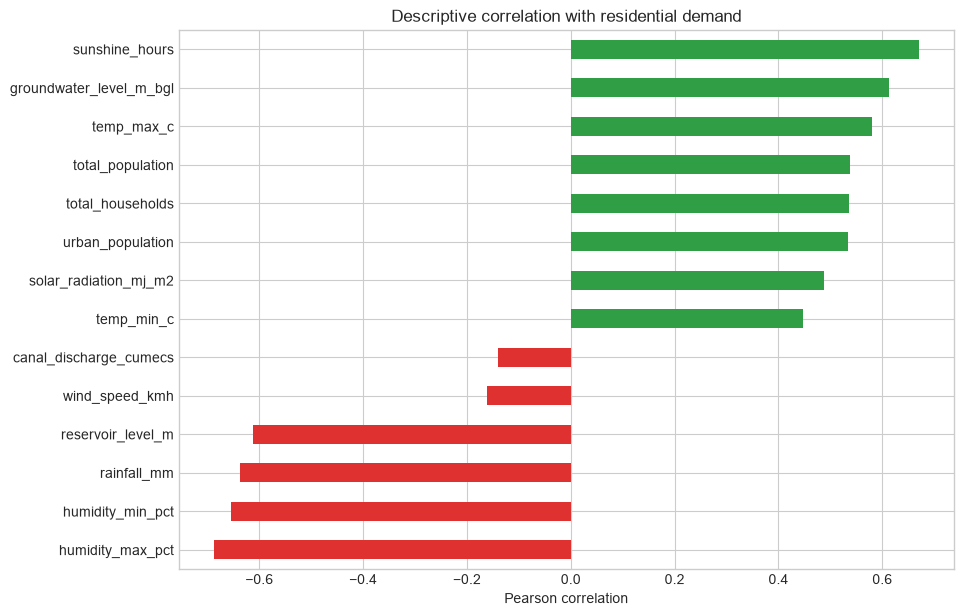

,lag_months,rainfall_corr,reservoir_corr,groundwater_corr
0,0,-0.637,-0.612,0.612
1,1,-0.540,-0.370,0.490
2,2,-0.372,-0.158,0.380
3,3,-0.119,-0.004,0.311
4,4,0.211,0.060,0.280
5,5,0.301,0.002,0.320
6,6,0.392,-0.095,0.359
7,7,0.392,-0.238,0.425
8,8,0.346,-0.388,0.488
9,9,0.177,-0.530,0.542


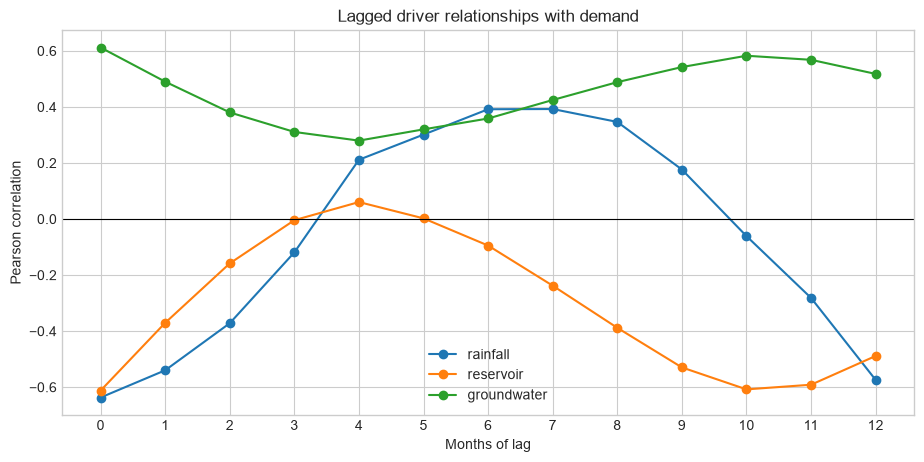

In [6]:
driver_columns = weather_columns + demographic_columns + state_columns
correlation_with_target = df[[target] + driver_columns].corr(numeric_only=True)[target].drop(target).sort_values()
display(correlation_with_target.to_frame('correlation_with_demand'))
fig, ax = plt.subplots(figsize=(10, 7))
correlation_with_target.plot(kind='barh', ax=ax, color=np.where(correlation_with_target >= 0, '#2f9e44', '#e03131'))
ax.set(title='Descriptive correlation with residential demand', xlabel='Pearson correlation')
fig.savefig(FIGURE_DIR / '05_driver_correlations.png', dpi=160, bbox_inches='tight')
plt.show()
lagged_relationships = pd.DataFrame({
    'lag_months': range(0, 13),
    'rainfall_corr': [df[target].corr(df['rainfall_mm'].shift(lag)) for lag in range(13)],
    'reservoir_corr': [df[target].corr(df['reservoir_level_m'].shift(lag)) for lag in range(13)],
    'groundwater_corr': [df[target].corr(df['groundwater_level_m_bgl'].shift(lag)) for lag in range(13)],
})
display(lagged_relationships)
fig, ax = plt.subplots(figsize=(11, 5))
for column in ['rainfall_corr','reservoir_corr','groundwater_corr']:
    ax.plot(lagged_relationships['lag_months'], lagged_relationships[column], marker='o', label=column.replace('_corr',''))
ax.axhline(0, color='black', linewidth=0.8)
ax.set(title='Lagged driver relationships with demand', xlabel='Months of lag', ylabel='Pearson correlation')
ax.set_xticks(range(13))
ax.legend()
fig.savefig(FIGURE_DIR / '06_lagged_driver_relationships.png', dpi=160)
plt.show()

## 7. Summary of findings

In [7]:
rainfall_ratio = df.loc[df['season']=='Monsoon','rainfall_mm'].mean() / df.loc[df['season']=='Dry season','rainfall_mm'].mean()
humidity_ratio = df.loc[df['season']=='Monsoon','humidity_max_pct'].mean() / df.loc[df['season']=='Dry season','humidity_max_pct'].mean()
sunshine_ratio = df.loc[df['season']=='Monsoon','sunshine_hours'].mean() / df.loc[df['season']=='Dry season','sunshine_hours'].mean()
findings = {
    'dataset_rows': int(len(df)),
    'date_range': f'{df.index.min():%Y-%m} to {df.index.max():%Y-%m}',
    'demand_mean_m3': float(df[target].mean()),
    'demand_std_m3': float(df[target].std()),
    'demand_cv': float(df[target].std() / df[target].mean()),
    'demand_growth_pct': float((df[target].iloc[-1] / df[target].iloc[0] - 1) * 100),
    'population_growth_pct': float((df['total_population'].iloc[-1] / df['total_population'].iloc[0] - 1) * 100),
    'household_growth_pct': float((df['total_households'].iloc[-1] / df['total_households'].iloc[0] - 1) * 100),
    'monsoon_months': monsoon_months,
    'monsoon_to_dry_rainfall_ratio': float(rainfall_ratio),
    'monsoon_to_dry_humidity_ratio': float(humidity_ratio),
    'monsoon_to_dry_sunshine_ratio': float(sunshine_ratio),
    'strongest_positive_driver': str(correlation_with_target.idxmax()),
    'strongest_negative_driver': str(correlation_with_target.idxmin()),
    'analysis_status': 'COMPLETE',
}
summary_path = REPORT_DIR / 'dnh_total_eda_summary.json'
summary_path.write_text(json.dumps(findings, indent=2))
display(pd.Series(findings, name='value').to_frame())
print(f'Saved analysis summary to {summary_path}')

,value
dataset_rows,180
date_range,2010-01 to 2024-12
demand_mean_m3,"3,660,509.559"
demand_std_m3,"697,758.949"
demand_cv,0.191
demand_growth_pct,38.914
population_growth_pct,44.929
household_growth_pct,38.827
monsoon_months,"[6, 7, 8, 9]"
monsoon_to_dry_rainfall_ratio,3.681


Saved analysis summary to C:\Users\derai\Desktop\ml_based_irrigation\outputs\reports\dnh_total_eda_summary.json


### Implications for forecasting

The analysis identifies the seasonal structure, major drivers, and candidate historical relationships that can inform a forecasting model. Feature selection and model construction should be performed separately, with careful controls to prevent future information from entering the predictors.